# 🎯 FIUS Ultrasonic Sensor — Data Loading & Exploration
## Classify: Human vs Chair vs Nothing
---
**What this notebook does:**
1. Loads your 3 big CSV files from Google Drive
2. Checks data quality (missing values, corrupted rows)
3. Visualizes echo signals from each class
4. Shows statistical differences between classes
5. Saves a summary report for us to review

```
My Drive/
└── VER Machine Learning Data/
    ├── signal_human.csv
    ├── signal_chair.csv
    └── signal_nothing.csv
```

## Cell 1 — Mount Google Drive & Install Libraries

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import os
from scipy import stats

warnings.filterwarnings('ignore')
print('✅ All libraries loaded successfully!')

Mounted at /content/drive
✅ All libraries loaded successfully!


## Cell 2 — Set File Paths

In [ ]:
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'  # ← Change this folder path

FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),     # ← Change filename
    'chair':   os.path.join(BASE_DIR, 'signal_chair2.csv'),     # ← Change filename
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),   # ← Change filename
}

# Verify files exist
print('Checking file paths...')
all_ok = True
for label, path in FILE_PATHS.items():
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / 1e6 if exists else 0
    status = f'✅ Found ({size_mb:.1f} MB)' if exists else '❌ NOT FOUND'
    print(f'  {label:8s}: {status}  →  {path}')
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ All files found! Proceed to next cell.')
else:
    print('\n❌ Some files missing! Please fix the paths above and re-run this cell.')

Checking file paths...
  human   : ✅ Found (763.5 MB)  →  /content/drive/MyDrive/VER Machine Learning Data/signal_human2.csv
  chair   : ✅ Found (754.0 MB)  →  /content/drive/MyDrive/VER Machine Learning Data/signal_chair2.csv
  nothing : ✅ Found (760.6 MB)  →  /content/drive/MyDrive/VER Machine Learning Data/signal_nothing.csv

✅ All files found! Proceed to next cell.


## Cell 3 — Load Data

In [ ]:
# ============================================================
# CELL 3 — MEMORY-EFFICIENT DATA LOADING
# ============================================================

import gc
import csv

N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125

def count_rows(filepath):
    """Count rows without loading file into memory."""
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, label, dtype=np.float32):
    """Load CSV in chunks to avoid RAM crash. Uses float32 instead of float64 (halves memory)."""
    print(f'  Counting rows...', end=' ')
    n_rows = count_rows(filepath)
    print(f'{n_rows} rows found.')

    # Pre-allocate arrays (float32 = half the memory of float64)
    metadata = np.empty((n_rows, N_METADATA_COLS), dtype=dtype)
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)

    print(f'  Loading...', end=' ')
    chunk_size = 100  # read 100 rows at a time
    row_idx = 0

    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        batch_rows = []
        for i, row in enumerate(reader):
            batch_rows.append(row)
            if len(batch_rows) == chunk_size:
                arr = np.array(batch_rows, dtype=dtype)
                n = arr.shape[0]
                metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
                signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n
                batch_rows = []
                if row_idx % 1000 == 0:
                    print(f'{row_idx}..', end=' ')

        # Handle remaining rows
        if batch_rows:
            arr = np.array(batch_rows, dtype=dtype)
            n = arr.shape[0]
            metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
            signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n

    # Trim in case we over-allocated
    metadata = metadata[:row_idx]
    signal = signal[:row_idx]
    print(f'Done! {row_idx} rows loaded.')
    return metadata, signal

# ---- Load each class ----
data = {}

for label, path in FILE_PATHS.items():
    print(f'\n📂 Loading {label.upper()} from: {path}')
    t0 = time.time()
    meta, sig = load_csv_efficient(path, label)
    dt = time.time() - t0
    data[label] = {'metadata': meta, 'signal': sig}
    print(f'  ✅ Shape: {sig.shape} | Time: {dt:.1f}s | RAM: ~{sig.nbytes/1e9:.2f} GB')
    gc.collect()  # force garbage collection

print(f'\n{"="*50}')
print(f'✅ ALL DATA LOADED SUCCESSFULLY!')
print(f'{"="*50}')
total = 0
for label in ['human', 'chair', 'nothing']:
    n = data[label]['signal'].shape[0]
    total += n
    print(f'  {label.upper():8s}: {n:6d} samples')
print(f'  {"TOTAL":8s}: {total:6d} samples')

total_ram_gb = sum(d['signal'].nbytes + d['metadata'].nbytes for d in data.values()) / 1e9
print(f'\n  Total RAM usage: ~{total_ram_gb:.2f} GB (using float32)')


📂 Loading HUMAN from: /content/drive/MyDrive/VER Machine Learning Data/signal_human2.csv
  Counting rows... 5005 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5005 rows loaded.
  ✅ Shape: (5005, 25000) | Time: 54.4s | RAM: ~0.50 GB

📂 Loading CHAIR from: /content/drive/MyDrive/VER Machine Learning Data/signal_chair2.csv
  Counting rows... 5000 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5000 rows loaded.
  ✅ Shape: (5000, 25000) | Time: 58.1s | RAM: ~0.50 GB

📂 Loading NOTHING from: /content/drive/MyDrive/VER Machine Learning Data/signal_nothing.csv
  Counting rows... 5002 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5002 rows loaded.
  ✅ Shape: (5002, 25000) | Time: 55.4s | RAM: ~0.50 GB

✅ ALL DATA LOADED SUCCESSFULLY!
  HUMAN   :   5005 samples
  CHAIR   :   5000 samples
  NOTHING :   5002 samples
  TOTAL   :  15007 samples

  Total RAM usage: ~1.50 GB (using float32)


## Cell 4 — Data Quality Check
Check for NaN values, infinite values, and corrupted rows.

In [ ]:
print('='*60)
print('DATA QUALITY REPORT')
print('='*60)

quality_report = {}

for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    meta = data[label]['metadata']
    n_rows = sig.shape[0]

    # Check for NaN
    nan_rows_signal = np.any(np.isnan(sig), axis=1).sum()
    nan_rows_meta = np.any(np.isnan(meta), axis=1).sum()

    # Check for infinite values
    inf_rows = np.any(np.isinf(sig), axis=1).sum()

    # Check for all-zero rows (dead signal)
    zero_rows = np.all(sig == 0, axis=1).sum()

    # Check signal range
    sig_min = np.nanmin(sig)
    sig_max = np.nanmax(sig)
    sig_mean = np.nanmean(sig)

    # Check col 11 (distance) and col 17 (energy)
    col11 = meta[:, 10]  # distance
    col17 = meta[:, 16]  # energy metric

    quality_report[label] = {
        'total_rows': n_rows,
        'nan_signal': nan_rows_signal,
        'nan_meta': nan_rows_meta,
        'inf_rows': inf_rows,
        'zero_rows': zero_rows,
    }

    print(f'\n--- {label.upper()} ---')
    print(f'  Total rows:        {n_rows}')
    print(f'  NaN in signal:     {nan_rows_signal} rows')
    print(f'  NaN in metadata:   {nan_rows_meta} rows')
    print(f'  Inf values:        {inf_rows} rows')
    print(f'  All-zero signals:  {zero_rows} rows')
    print(f'  Signal range:      [{sig_min:.1f}, {sig_max:.1f}]')
    print(f'  Signal mean:       {sig_mean:.2f}')
    print(f'  Distance (col 11): mean={np.nanmean(col11):.3f}m, range=[{np.nanmin(col11):.3f}, {np.nanmax(col11):.3f}]')
    print(f'  Energy (col 17):   mean={np.nanmean(col17):.1f}, range=[{np.nanmin(col17):.1f}, {np.nanmax(col17):.1f}]')

# Summary
total_bad = sum(v['nan_signal'] + v['inf_rows'] + v['zero_rows'] for v in quality_report.values())
if total_bad == 0:
    print('\n✅ DATA IS CLEAN — No NaN, no Inf, no dead rows!')
else:
    print(f'\n⚠️  Found {total_bad} problematic rows — we will handle them in Step 2.')

DATA QUALITY REPORT

--- HUMAN ---
  Total rows:        5005
  NaN in signal:     0 rows
  NaN in metadata:   0 rows
  Inf values:        0 rows
  All-zero signals:  0 rows
  Signal range:      [-3600.0, 3485.0]
  Signal mean:       -68.49
  Distance (col 11): mean=0.569m, range=[0.000, 6.041]
  Energy (col 17):   mean=316177.2, range=[136302.6, 487145.7]

--- CHAIR ---
  Total rows:        5000
  NaN in signal:     0 rows
  NaN in metadata:   0 rows
  Inf values:        0 rows
  All-zero signals:  0 rows
  Signal range:      [-1536.0, 1346.0]
  Signal mean:       -63.32
  Distance (col 11): mean=1.451m, range=[1.446, 1.461]
  Energy (col 17):   mean=428409.8, range=[3299.2, 826018.7]

--- NOTHING ---
  Total rows:        5002
  NaN in signal:     0 rows
  NaN in metadata:   0 rows
  Inf values:        0 rows
  All-zero signals:  0 rows
  Signal range:      [-8192.0, 8190.0]
  Signal mean:       -66.04
  Distance (col 11): mean=2.192m, range=[1.796, 2.256]
  Energy (col 17):   mean=184

## Cell 5 — Visualize: Sample Echo Signals from Each Class
Shows 5 random signals per class to see echo patterns.

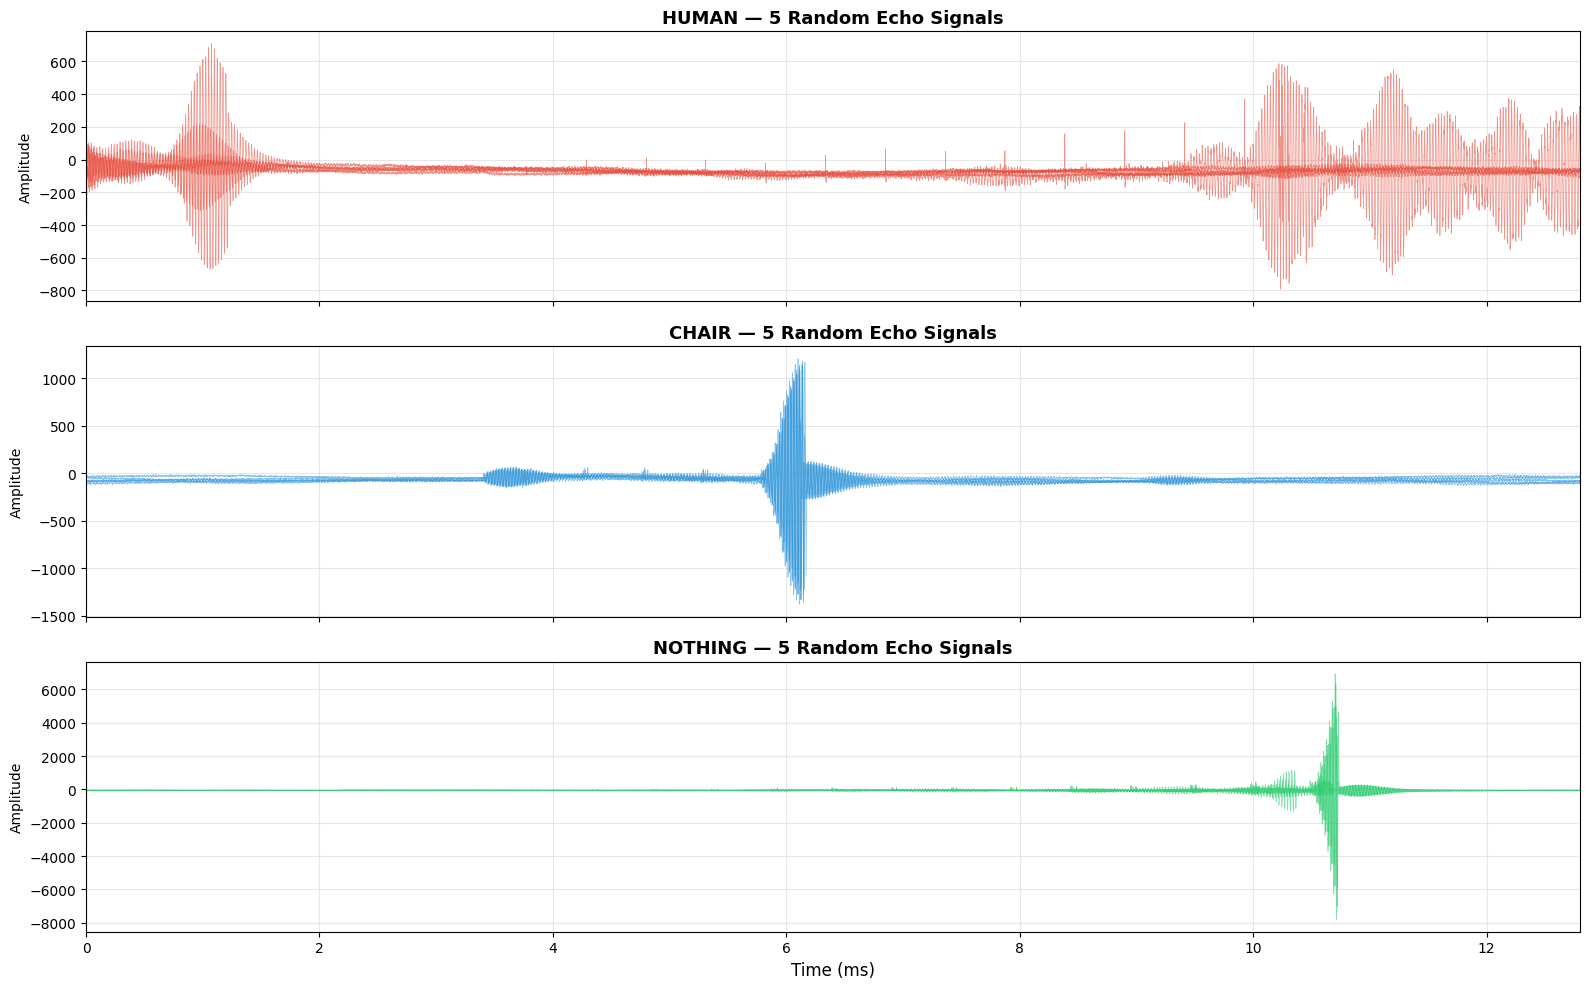

✅ Plot saved as step1_sample_signals.png


In [ ]:
time_ms = np.arange(N_SIGNAL_SAMPLES) / SAMPLING_RATE * 1000  # time axis in ms

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
colors = {'human': '#e74c3c', 'chair': '#3498db', 'nothing': '#2ecc71'}

np.random.seed(42)
for idx, label in enumerate(['human', 'chair', 'nothing']):
    ax = axes[idx]
    sig = data[label]['signal']
    n = sig.shape[0]

    # Pick 5 random samples
    sample_idxs = np.random.choice(n, size=min(5, n), replace=False)
    for i in sample_idxs:
        ax.plot(time_ms, sig[i], alpha=0.6, linewidth=0.5, color=colors[label])

    ax.set_title(f'{label.upper()} — 5 Random Echo Signals', fontsize=13, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, time_ms[-1])

axes[-1].set_xlabel('Time (ms)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/step1_sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as step1_sample_signals.png')

## Cell 6 — Visualize: Mean Signal Comparison (All 3 Classes Overlaid)

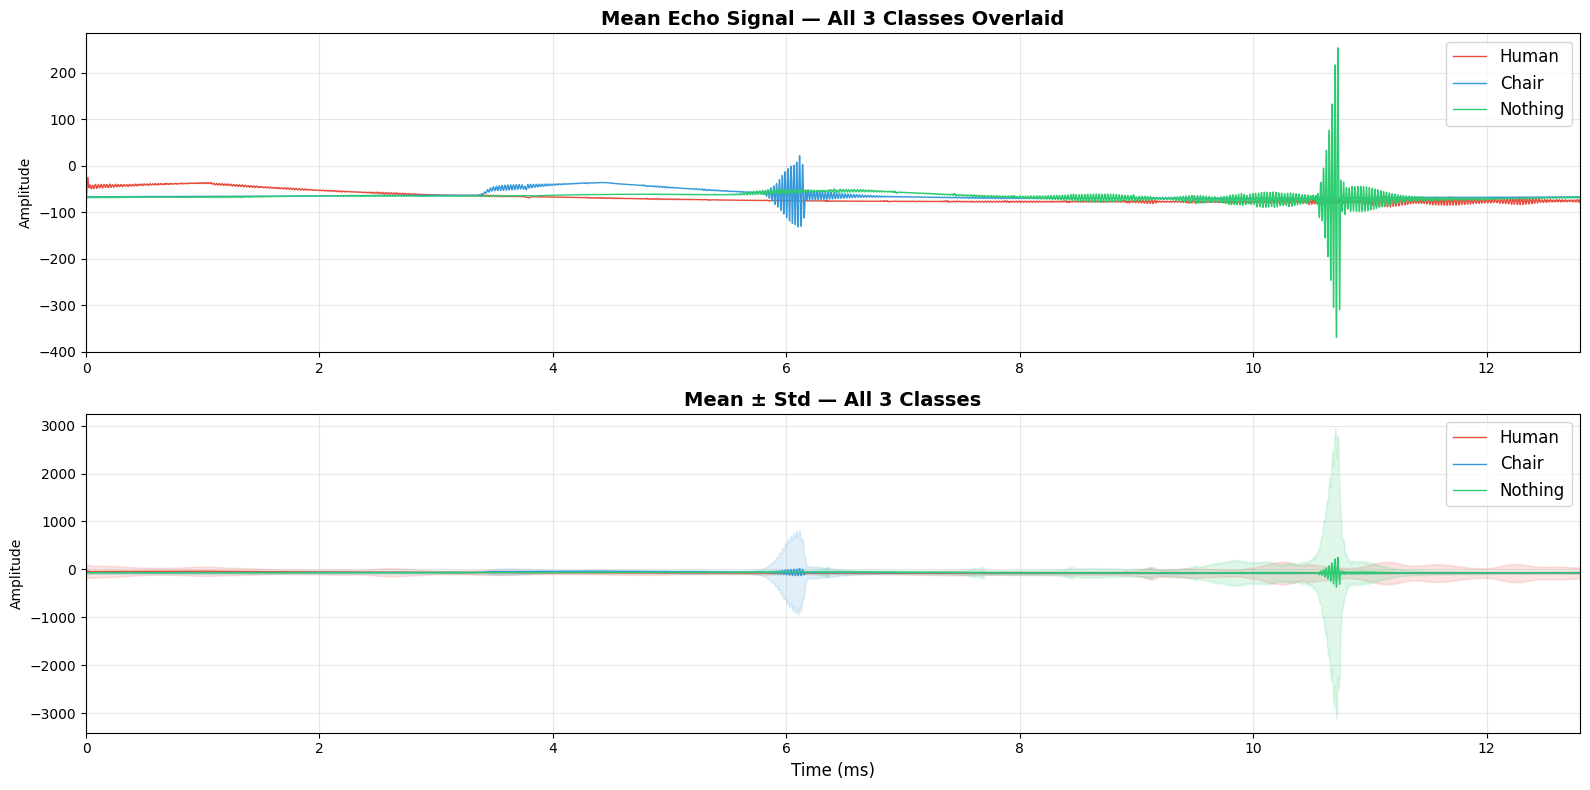

✅ Plot saved as step1_mean_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top: Mean signals overlaid
ax = axes[0]
for label in ['human', 'chair', 'nothing']:
    mean_sig = np.mean(data[label]['signal'], axis=0)
    ax.plot(time_ms, mean_sig, color=colors[label], label=label.capitalize(), linewidth=1)
ax.set_title('Mean Echo Signal — All 3 Classes Overlaid', fontsize=14, fontweight='bold')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, time_ms[-1])

# Bottom: Mean ± Std for each class
ax = axes[1]
for label in ['human', 'chair', 'nothing']:
    mean_sig = np.mean(data[label]['signal'], axis=0)
    std_sig = np.std(data[label]['signal'], axis=0)
    ax.plot(time_ms, mean_sig, color=colors[label], label=label.capitalize(), linewidth=1)
    ax.fill_between(time_ms, mean_sig - std_sig, mean_sig + std_sig,
                    color=colors[label], alpha=0.15)
ax.set_title('Mean ± Std — All 3 Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Amplitude')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, time_ms[-1])

plt.tight_layout()
plt.savefig('/content/step1_mean_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as step1_mean_comparison.png')

## Cell 7 — Visualize: Signal Energy Distribution per Class
This shows how the total energy of the echo differs between classes.

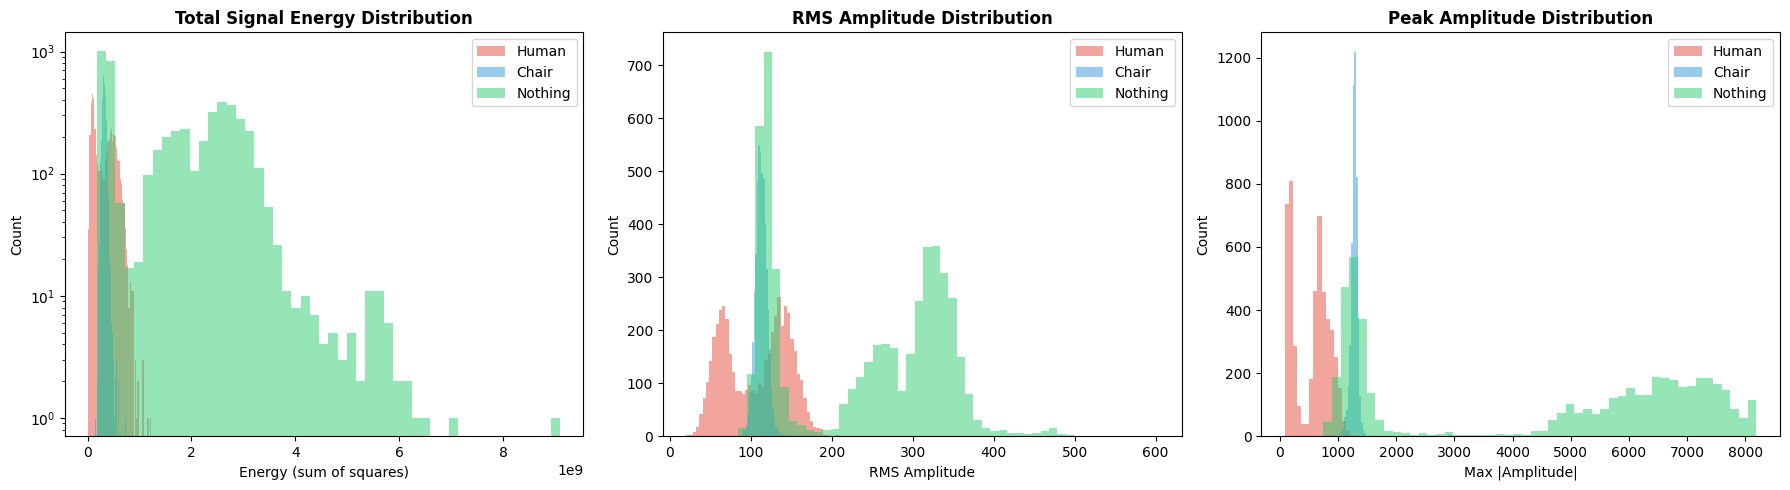

✅ Plot saved as step1_energy_distributions.png


In [ ]:
# Compute signal energy (sum of squares) for each sample
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total signal energy histogram
ax = axes[0]
for label in ['human', 'chair', 'nothing']:
    energy = np.sum(data[label]['signal'] ** 2, axis=1)
    ax.hist(energy, bins=50, alpha=0.5, label=label.capitalize(), color=colors[label])
ax.set_title('Total Signal Energy Distribution', fontweight='bold')
ax.set_xlabel('Energy (sum of squares)')
ax.set_ylabel('Count')
ax.legend()
ax.set_yscale('log')

# 2. RMS amplitude histogram
ax = axes[1]
for label in ['human', 'chair', 'nothing']:
    rms = np.sqrt(np.mean(data[label]['signal'] ** 2, axis=1))
    ax.hist(rms, bins=50, alpha=0.5, label=label.capitalize(), color=colors[label])
ax.set_title('RMS Amplitude Distribution', fontweight='bold')
ax.set_xlabel('RMS Amplitude')
ax.set_ylabel('Count')
ax.legend()

# 3. Peak amplitude histogram
ax = axes[2]
for label in ['human', 'chair', 'nothing']:
    peak = np.max(np.abs(data[label]['signal']), axis=1)
    ax.hist(peak, bins=50, alpha=0.5, label=label.capitalize(), color=colors[label])
ax.set_title('Peak Amplitude Distribution', fontweight='bold')
ax.set_xlabel('Max |Amplitude|')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('/content/step1_energy_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as step1_energy_distributions.png')

## Cell 8 — Visualize: Metadata Column 11 (Distance) & Column 17 (Energy Metric)

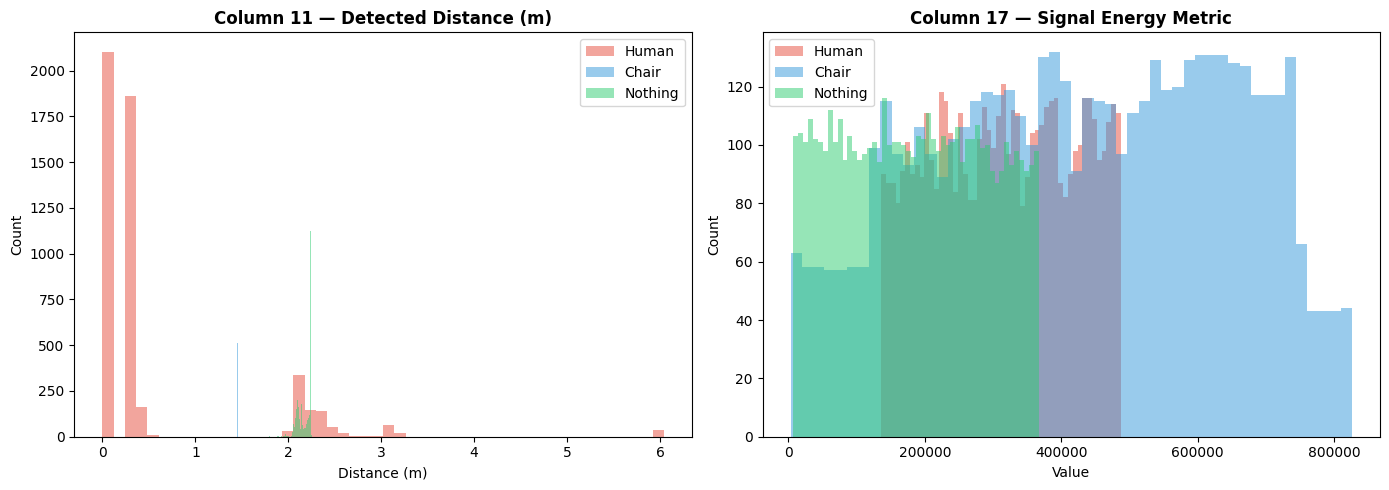

✅ Plot saved as step1_metadata_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Column 11 — Distance
ax = axes[0]
for label in ['human', 'chair', 'nothing']:
    col11 = data[label]['metadata'][:, 10]
    ax.hist(col11, bins=50, alpha=0.5, label=label.capitalize(), color=colors[label])
ax.set_title('Column 11 — Detected Distance (m)', fontweight='bold')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Count')
ax.legend()

# Column 17 — Energy metric
ax = axes[1]
for label in ['human', 'chair', 'nothing']:
    col17 = data[label]['metadata'][:, 16]
    ax.hist(col17, bins=50, alpha=0.5, label=label.capitalize(), color=colors[label])
ax.set_title('Column 17 — Signal Energy Metric', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('/content/step1_metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as step1_metadata_distributions.png')

## Cell 9 — Segmented Energy Analysis
Divide the 25,000-sample signal into 25 windows of 1000 samples each.
This shows WHERE in time the energy is concentrated for each class.

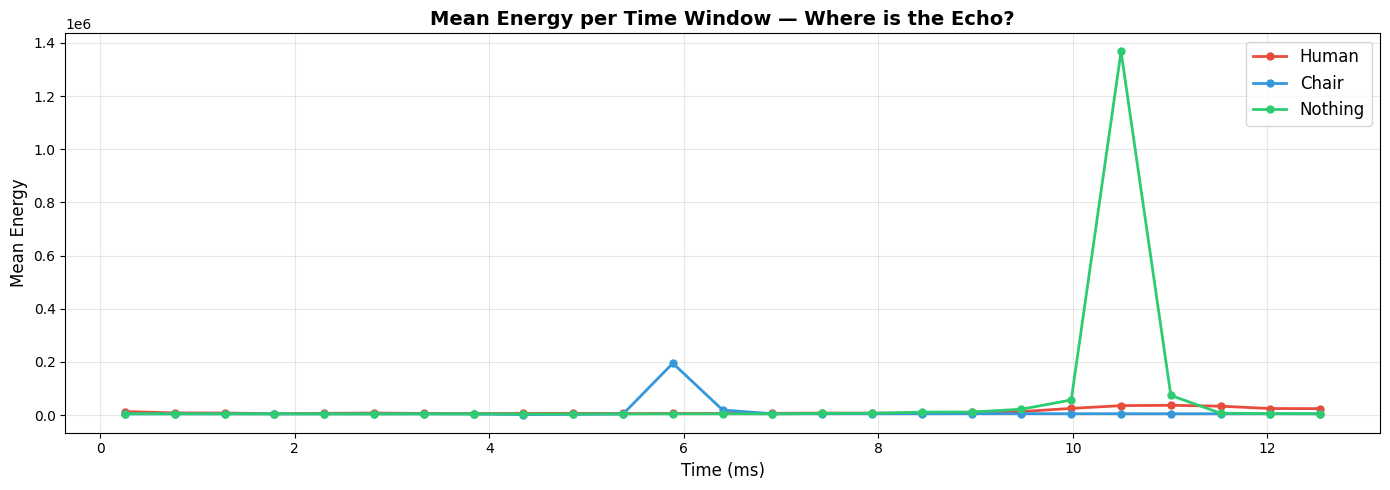

✅ Plot saved as step1_segmented_energy.png


In [ ]:
N_WINDOWS = 25
WINDOW_SIZE = N_SIGNAL_SAMPLES // N_WINDOWS  # 1000 samples per window

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

window_centers_ms = [(i * WINDOW_SIZE + WINDOW_SIZE // 2) / SAMPLING_RATE * 1000
                     for i in range(N_WINDOWS)]

for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    # Reshape to (n_samples, n_windows, window_size) and compute energy per window
    sig_windowed = sig[:, :N_WINDOWS * WINDOW_SIZE].reshape(sig.shape[0], N_WINDOWS, WINDOW_SIZE)
    energy_per_window = np.mean(sig_windowed ** 2, axis=2)  # (n_samples, n_windows)
    mean_energy = np.mean(energy_per_window, axis=0)        # (n_windows,)

    ax.plot(window_centers_ms, mean_energy, 'o-', color=colors[label],
            label=label.capitalize(), linewidth=2, markersize=5)

ax.set_title('Mean Energy per Time Window — Where is the Echo?', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Mean Energy', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/step1_segmented_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as step1_segmented_energy.png')

## Cell 10 — Final Summary Report

In [ ]:
print('=' * 65)
print('        STEP 1 — DATA EXPLORATION SUMMARY REPORT')
print('=' * 65)

for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    col11 = data[label]['metadata'][:, 10]
    col17 = data[label]['metadata'][:, 16]

    rms = np.sqrt(np.mean(sig ** 2, axis=1))
    peak = np.max(np.abs(sig), axis=1)
    energy = np.sum(sig ** 2, axis=1)

    nan_count = np.any(np.isnan(sig), axis=1).sum()

    print(f'\n--- {label.upper()} ---')
    print(f'  Samples:           {sig.shape[0]}')
    print(f'  Signal length:     {sig.shape[1]}')
    print(f'  NaN rows:          {nan_count}')
    print(f'  RMS amplitude:     mean={np.mean(rms):.2f}, std={np.std(rms):.2f}')
    print(f'  Peak amplitude:    mean={np.mean(peak):.1f}, std={np.std(peak):.1f}')
    print(f'  Total energy:      mean={np.mean(energy):.0f}, std={np.std(energy):.0f}')
    print(f'  Distance (col 11): mean={np.mean(col11):.3f}m, std={np.std(col11):.3f}')
    print(f'  Energy (col 17):   mean={np.mean(col17):.1f}, std={np.std(col17):.1f}')

print('\n' + '=' * 65)
print('CLASS BALANCE:')
total = sum(data[l]['signal'].shape[0] for l in ['human', 'chair', 'nothing'])
for label in ['human', 'chair', 'nothing']:
    n = data[label]['signal'].shape[0]
    print(f'  {label.upper():8s}: {n:6d} samples ({n/total*100:.1f}%)')
print(f'  {"TOTAL":8s}: {total:6d} samples')

print('\n' + '=' * 65)
print('NEXT STEP:')
print('  Copy the text above and share it back with me.')
print('  Also share the 6 plots generated above (screenshot is fine).')
print('  Then I will create Step 2 — Preprocessing & Feature Engineering.')
print('=' * 65)

        STEP 1 — DATA EXPLORATION SUMMARY REPORT

--- HUMAN ---
  Samples:           5001
  Signal length:     25000
  NaN rows:          0
  RMS amplitude:     mean=130.52, std=15.55
  Peak amplitude:    mean=1062.8, std=153.2
  Total energy:      mean=431947648, std=107009888
  Distance (col 11): mean=2.380m, std=0.194
  Energy (col 17):   mean=268816.6, std=116462.9

--- CHAIR ---
  Samples:           5000
  Signal length:     25000
  NaN rows:          0
  RMS amplitude:     mean=128.70, std=9.88
  Peak amplitude:    mean=1222.8, std=118.3
  Total energy:      mean=416543872, std=62418888
  Distance (col 11): mean=2.221m, std=0.082
  Energy (col 17):   mean=316802.5, std=177806.5

--- NOTHING ---
  Samples:           5002
  Signal length:     25000
  NaN rows:          0
  RMS amplitude:     mean=236.17, std=99.10
  Peak amplitude:    mean=4519.4, std=2652.6
  Total energy:      mean=1639925120, std=1172754688
  Distance (col 11): mean=2.192m, std=0.065
  Energy (col 17):   mean=18